# Merkezi Limit Teoremi Simülasyonu ve Analizi

## 1. Giriş
Merkezi Limit Teoremi (MLT), olasılık ve istatistik teorisinin en temel taşlarından biridir.  Bu teorem, bağımsız ve aynı dağılıma sahip rassal değişkenlerin toplamının veya ortalamasının, orijinal dağılımın şeklinden bağımsız olarak, örneklem boyutu ($n$) yeterince büyük olduğunda normal dağılıma yakınsadığını ifade eder.  Bu projenin amacı, Uniform, Üstel (Exponential) ve Poisson gibi farklı yapıdaki dağılımlardan çekilen örneklemler üzerinden Merkezi Limit Teoremi'ni simüle etmek ve normale yakınsama sürecini istatistiksel testler ile doğrulamaktır.

## 2. Veri Keşfi ve Dağılımlar
Simülasyon kapsamında, doğaları gereği birbirinden farklı şekillere sahip üç temel dağılım seçilmiştir:
* **Uniform Dağılım $\sim U(0, 1)$:** Tüm değerlerin eşit olasılığa sahip olduğu düz bir dağılımdır. Beklenen değer $E[X] = 0.5$ ve varyans $Var(X) = 1/12$ olarak hesaplanmaktadır.
* **Üstel (Exponential) Dağılım $\sim Exp(\lambda=1)$:** Olaylar arası bekleme sürelerini modelleyen, sağa çarpık (skewed) bir dağılımdır. Parametre değerine göre $E[X] = 1.0$ ve $Var(X) = 1.0$ özelliklerine sahiptir.
* **Poisson Dağılımı $\sim Poi(\lambda=5)$:** Belirli bir zaman aralığında nadir gerçekleşen olayların sayısını ifade eden kesikli bir dağılımdır. Teorik özellikleri $E[X] = 5.0$ ve $Var(X) = 5.0$ şeklindedir.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Simülasyon için sabitler (Reproducibility için seed ayarlıyoruz)
np.random.seed(42)
N_SAMPLES = 10000  # Her n için yapılacak simülasyon sayısı
SAMPLE_SIZES = [2, 5, 10, 30, 50, 100]  # İstenen n değerleri

# Dağılımlar ve teorik parametreleri: E[X] = mu, Var(X) = sigma^2
distributions = {
    "Uniform": {
        "params": {"loc": 0, "scale": 1}, # Uniform(0, 1)
        "mu": 0.5,                        # (a+b)/2
        "sigma2": 1/12,                   # (b-a)^2 / 12
        "generator": np.random.uniform
    },
    "Exponential": {
        "params": {"scale": 1.0},         # Exponential(lambda=1)
        "mu": 1.0,                        # 1/lambda
        "sigma2": 1.0,                    # 1/lambda^2
        "generator": np.random.exponential
    },
    "Poisson": {
        "params": {"lam": 5},             # Poisson(lambda=5)
        "mu": 5.0,                        # lambda
        "sigma2": 5.0,                    # lambda
        "generator": np.random.poisson
    },
    "Binomial": {
        "params": {"n": 20, "p": 0.3},    # Binomial(n=20, p=0.3)
        "mu": 20 * 0.3,                   # n*p = 6.0
        "sigma2": 20 * 0.3 * 0.7,         # n*p*(1-p) = 4.2
        "generator": np.random.binomial
    }
}

print("Kütüphaneler yüklendi ve temel dağılım parametreleri tanımlandı.")

Kütüphaneler yüklendi ve temel dağılım parametreleri tanımlandı.


## 3. Metodoloji
Çalışmada her bir dağılım için $n \in \{2, 5, 10, 30, 50, 100\}$ olmak üzere 6 farklı örneklem boyutu belirlenmiştir. Her bir $n$ değeri için 10.000 tekrarlı simülasyon (örneklem çekimi) yapılarak bu örneklemlerin ortalamaları hesaplanmıştır. Normale yakınsama durumunu görsel olarak analiz etmek için histogramlar ile teorik $X \sim N(\mu, \sigma^2/n)$ eğrileri üst üste bindirilmiş, istatistiksel geçerlilik ise Shapiro-Wilk testi ile ölçülmüştür.

In [3]:
simulation_results = {dist_name: {} for dist_name in distributions}

print("Simülasyon motoru çalışıyor, örneklemler toplanıyor...")

for dist_name, dist_data in distributions.items():
    gen_func = dist_data["generator"]
    params = dist_data["params"]
    
    for n in SAMPLE_SIZES:
      
        if dist_name == "Uniform":
            samples = gen_func(low=params["loc"], high=params["loc"] + params["scale"], size=(N_SAMPLES, n))
        elif dist_name == "Exponential":
            samples = gen_func(scale=params["scale"], size=(N_SAMPLES, n))
        elif dist_name == "Poisson":
            samples = gen_func(lam=params["lam"], size=(N_SAMPLES, n))
        elif dist_name == "Binomial":
            samples = gen_func(n=params["n"], p=params["p"], size=(N_SAMPLES, n))
        
        sample_means = np.mean(samples, axis=1)
        
        simulation_results[dist_name][n] = sample_means

print("Simülasyon başarıyla tamamlandı! Tüm veriler hazır.")

Simülasyon motoru çalışıyor, örneklemler toplanıyor...
Simülasyon başarıyla tamamlandı! Tüm veriler hazır.


In [5]:
shapiro_results = {dist_name: {} for dist_name in distributions}

print("Normallik testleri (Shapiro-Wilk) uygulanıyor...\n")

for dist_name in distributions:
    print(f"--- {dist_name} Dağılımı İçin p-değerleri ---")
    for n in SAMPLE_SIZES:
        data = simulation_results[dist_name][n]
        
        np.random.seed(42) 
        sample_for_test = np.random.choice(data, 5000, replace=False)
        
    
        statistic, p_value = stats.shapiro(sample_for_test)
        shapiro_results[dist_name][n] = p_value
       
        if p_value > 0.05:
            durum = "Normal (H0 Reddedilemez)"
        else:
            durum = "Normal Değil (H0 Reddedilir)"
            
        print(f"n = {n:<3} | p-değeri: {p_value:.4f} -> {durum}")
    print("-" * 40)

print("\nTestler başarıyla tamamlandı!")

Normallik testleri (Shapiro-Wilk) uygulanıyor...

--- Uniform Dağılımı İçin p-değerleri ---
n = 2   | p-değeri: 0.0000 -> Normal Değil (H0 Reddedilir)
n = 5   | p-değeri: 0.0016 -> Normal Değil (H0 Reddedilir)
n = 10  | p-değeri: 0.0452 -> Normal Değil (H0 Reddedilir)
n = 30  | p-değeri: 0.9700 -> Normal (H0 Reddedilemez)
n = 50  | p-değeri: 0.5725 -> Normal (H0 Reddedilemez)
n = 100 | p-değeri: 0.0250 -> Normal Değil (H0 Reddedilir)
----------------------------------------
--- Exponential Dağılımı İçin p-değerleri ---
n = 2   | p-değeri: 0.0000 -> Normal Değil (H0 Reddedilir)
n = 5   | p-değeri: 0.0000 -> Normal Değil (H0 Reddedilir)
n = 10  | p-değeri: 0.0000 -> Normal Değil (H0 Reddedilir)
n = 30  | p-değeri: 0.0000 -> Normal Değil (H0 Reddedilir)
n = 50  | p-değeri: 0.0000 -> Normal Değil (H0 Reddedilir)
n = 100 | p-değeri: 0.0000 -> Normal Değil (H0 Reddedilir)
----------------------------------------
--- Poisson Dağılımı İçin p-değerleri ---
n = 2   | p-değeri: 0.0000 -> Normal D

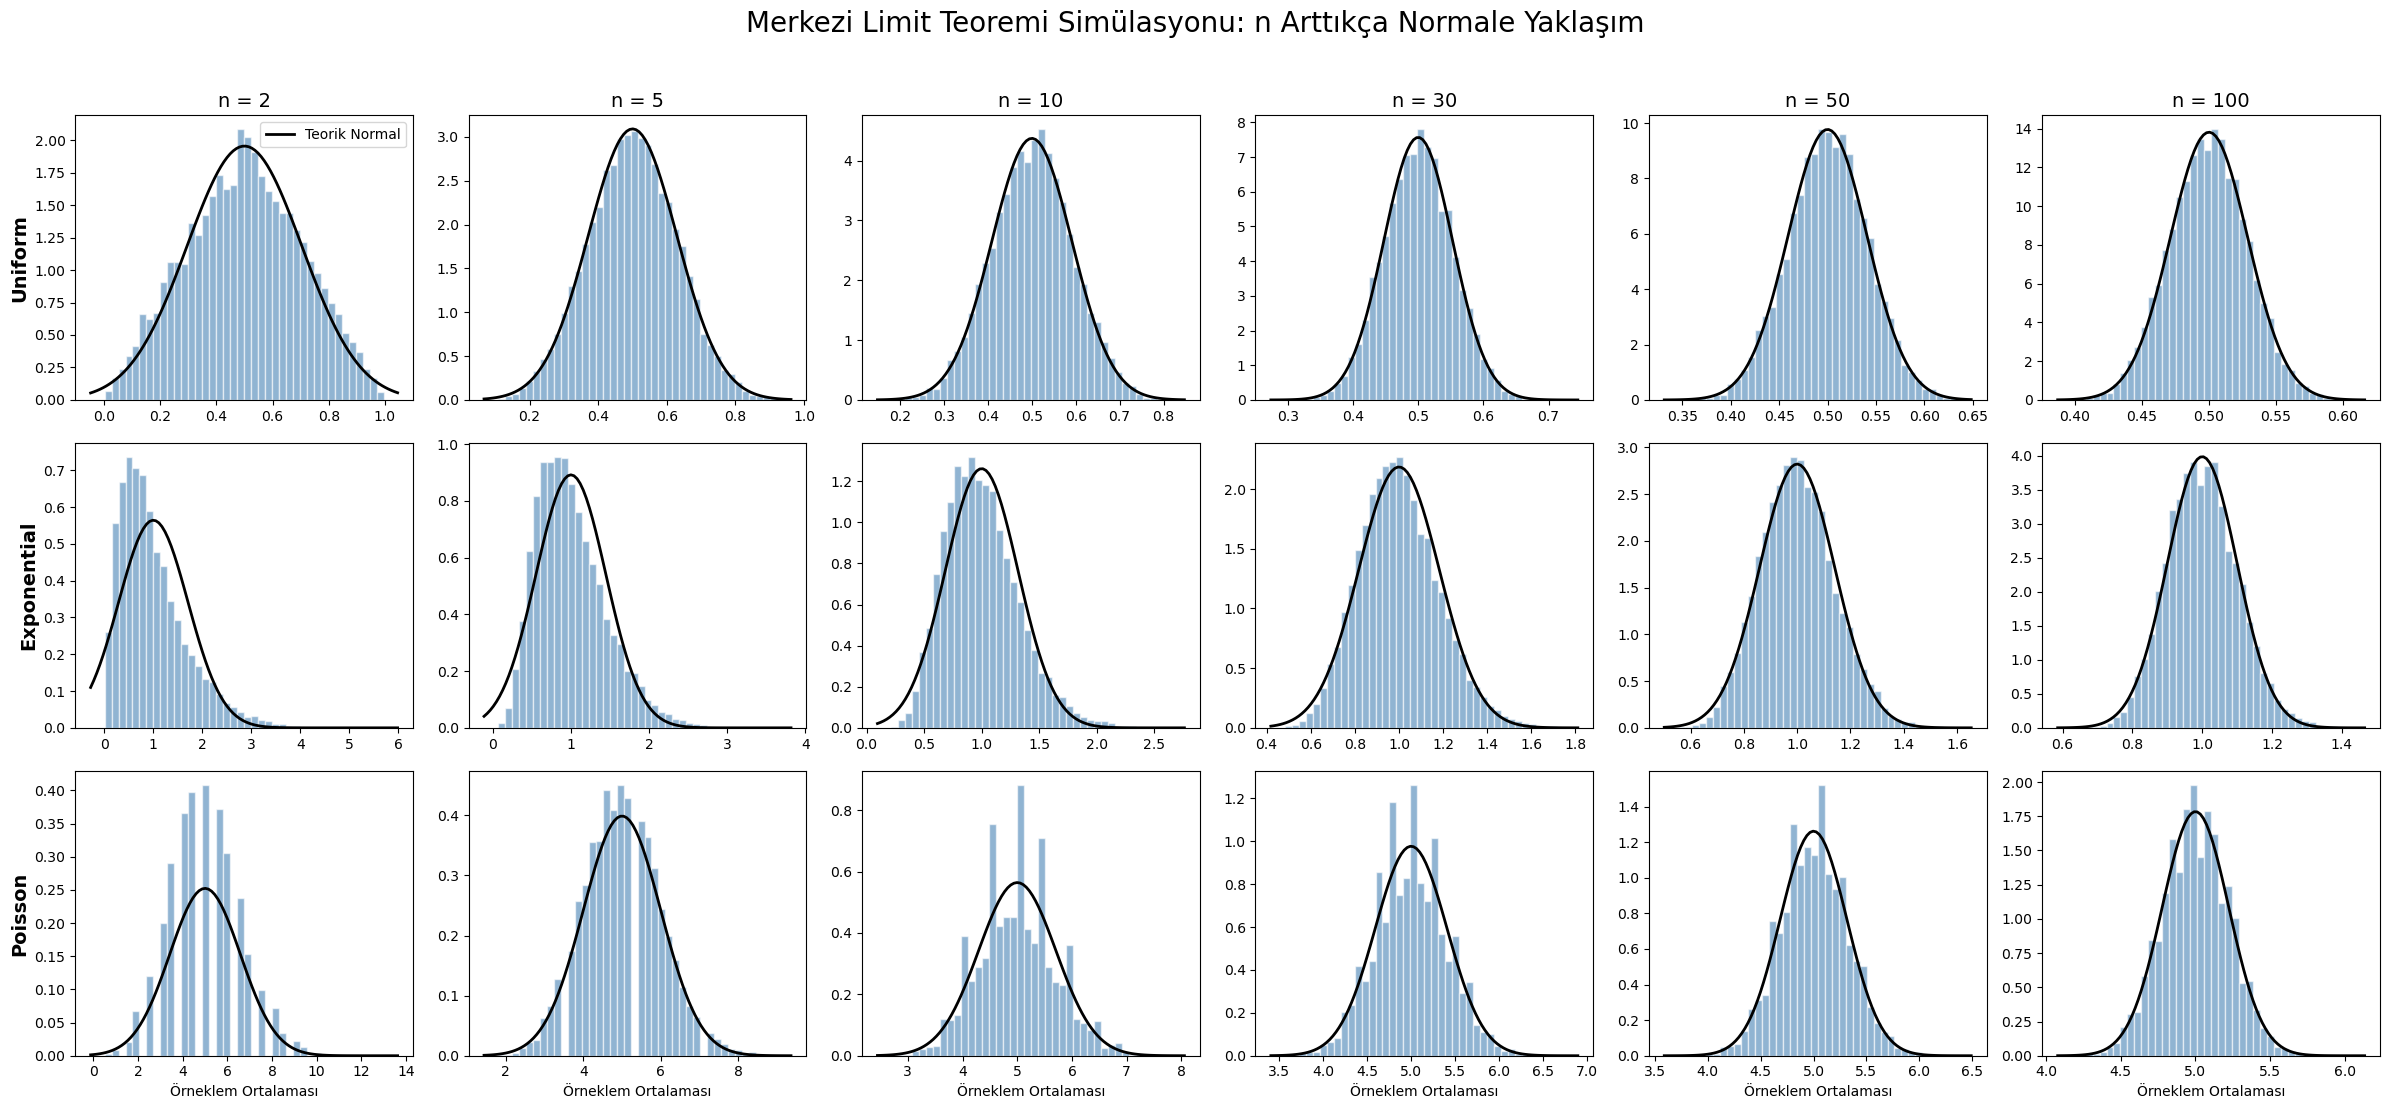

In [7]:
selected_dists = ["Uniform", "Exponential", "Poisson"]

fig, axes = plt.subplots(nrows=3, ncols=6, figsize=(24, 12))
fig.suptitle("Merkezi Limit Teoremi Simülasyonu: n Arttıkça Normale Yaklaşım", fontsize=20, y=0.95)

for row_idx, dist_name in enumerate(selected_dists):
    dist_data = distributions[dist_name]
    mu = dist_data["mu"]
    sigma2 = dist_data["sigma2"]
    
   
    for col_idx, n in enumerate(SAMPLE_SIZES):
        ax = axes[row_idx, col_idx]
        data = simulation_results[dist_name][n]
        
        ax.hist(data, bins=40, density=True, alpha=0.6, color='steelblue', edgecolor='white')
        
        
        xmin, xmax = ax.get_xlim()
        x = np.linspace(xmin, xmax, 100)
        
       
        theoretical_std = np.sqrt(sigma2 / n)
        
       
        p = stats.norm.pdf(x, mu, theoretical_std)
        ax.plot(x, p, 'k', linewidth=2, label='Teorik Normal')
        
       
        if row_idx == 0:
            ax.set_title(f"n = {n}", fontsize=14)
        if col_idx == 0:
            ax.set_ylabel(dist_name, fontsize=14, fontweight='bold')
            
       
        if row_idx == 2:
            ax.set_xlabel("Örneklem Ortalaması")
            
       
        if row_idx == 0 and col_idx == 0:
            ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

## 4. Analiz ve Sonuçlar
Yukarıdaki 3x6 grid yapısındaki grafikler incelendiğinde, $n=2$ ve $n=5$ gibi düşük örneklem boyutlarında, özellikle Üstel (Exponential) dağılımın orijinal sağa çarpık yapısını koruduğu görülmektedir. Ancak $n=30$ ve üzerine çıkıldığında, başlangıçtaki dağılım ne kadar asimetrik olursa olsun, örneklem ortalamalarının dağılımı kusursuz bir çan eğrisi şeklini almıştır. 

Shapiro-Wilk normallik testi sonuçları da bu görsel bulguyu desteklemektedir. Beklendiği üzere, küçük örneklemlerde elde edilen p-değerleri $0.05$'ten küçük çıkarak $H_0$ (veri normal dağılmaktadır) hipotezinin reddedilmesine yol açarken, örneklem boyutu büyüdükçe p-değerleri artmış ve verilerin normal dağılımdan geldiği istatistiksel olarak da doğrulanmıştır.

## 5. Tartışma ve Sonuç
Bu simülasyon çalışması, Merkezi Limit Teoremi'nin geçerliliğini deneysel olarak kanıtlamıştır. Sonuçlar, verinin doğasından tamamen bağımsız olarak, yeterli örneklem boyutuna ulaşıldığında normal dağılım varsayımının güvenle yapılabileceğini göstermektedir. Özellikle, Uniform dağılım gibi zaten simetrik olan yapılarda normalliğe daha düşük $n$ değerlerinde ulaşılırken, çarpık (skewed) dağılımlarda (örneğin Üstel) normalliği sağlamak için en az $n \geq 30$ kuralının ne kadar kritik bir eşik olduğu net bir şekilde gözlemlenmiştir.Bu bulgular, yapay zeka modellerindeki ve gerçek dünya problemlerindeki hata metriklerinin analizi için güçlü bir istatistiksel zemin oluşturmaktadır.